# Model Spikey observed by *Plato* with JAXNS

In this notebook we use the Bayesian inference package `JAXNS`, using nested sampling, to model the Plato simulation of Spikey.

In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib widget

In [6]:
# Built-in
import os
import sys
import json
import copy
import warnings

# Dependencies
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from jax import numpy as jnp
import numpyro
import numpyro.distributions as dist

# Select number of CPUs
numpyro.enable_x64()
numpyro.set_host_device_count(6)

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_jax
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

In [7]:
# Hide warnings
warnings.filterwarnings("ignore")

In [8]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'
fdir = path / 'figures'
cv = 'tomato'
cm = 'orange'
c0 = 'lightseagreen'
c1 = 'mediumorchid'

---
## 1. *Plato* 2-yr light curve
---

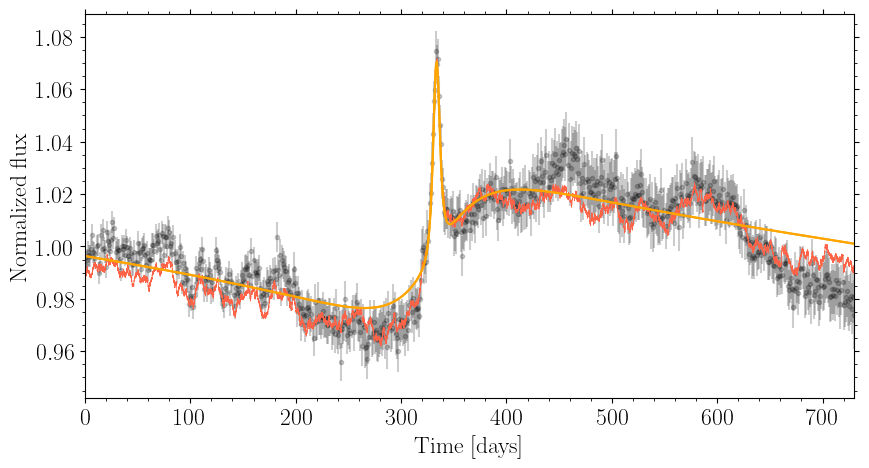

In [10]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_feather(ddir / 'lc_spikey_plato_fiducial.ftr')
dv = pd.read_feather(ddir / 'lc_spikey_plato_template.ftr')
Q0=9

# Bin to 1-hour light curve 
df = ut.bin_lc(df, bin_size=1)

# Cut light curve to 2-year duration
df = df[df.time < 4*ut.year2day()]

# Generate relativistic Spikey model
params = smbhb.model_params()
params.t0    = 0.712
params.sigma = 0 
model = smbhb.model(params)
dm = model.light_curve(df.time.to_numpy(), df=True)

# Reset time arrays
t0 = df.time.iloc[0]
df.time -= t0
dv.time -= t0
dm.time -= t0

# Secure mean level
df.flux -= (np.mean(df.flux) - 1)
time = df.time.to_numpy()
flux = df.flux.to_numpy()

# Load default model priors
priors_DM  = bs.model_priors(params, model='DM') 
priors_Q   = bs.model_priors(params, model='Q',   flux=flux) 
priors_QDM = bs.model_priors(params, model='QDM', flux=flux) 

# Plot light curve
fig, ax = pt.plot_lc(df, dv, cm=cv, lw=0.5)
ax.plot(dm.time, dm.flux, '-', c=cm)
ax.plot(dm.time, dm.flux, '-', c=cm);

---
### 1.1. Model Q
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 7595490
samples: 31062
phantom samples: 0
likelihood evals / sample: 244.5
phantom fraction (%): 0.0%
--------
logZ=2630.282 +- 0.062
max(logL)=2636.926
H=-5.31
ESS=2977
--------
mean: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
mean: 0.996 +- 0.014 | 0.979 / 0.997 / 1.012 | 0.997 | 0.997
--------
sigma: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
sigma: 0.0228 +- 0.0058 | 0.0165 / 0.0218 / 0.0305 | 0.0191 | 0.0191
--------
tau: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
tau: 180.0 +- 100.0 | 90.0 / 160.0 / 310.0 | 120.0 | 120.0
--------
CPU times: user 1h 10min 8s, sys: 3min 46s, total: 1h 13min 55s
Wall time: 25min 58s

```

In [9]:
filename = rdir / 'spikey_plato_jaxns_2yr24h_Q.npy'

In [34]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors_Q, 
#     build_mean=None, 
#     build_kernel=bs.drw_kernel, 
#     ofile=filename
# )

In [19]:
result = ut.load_result(filename)

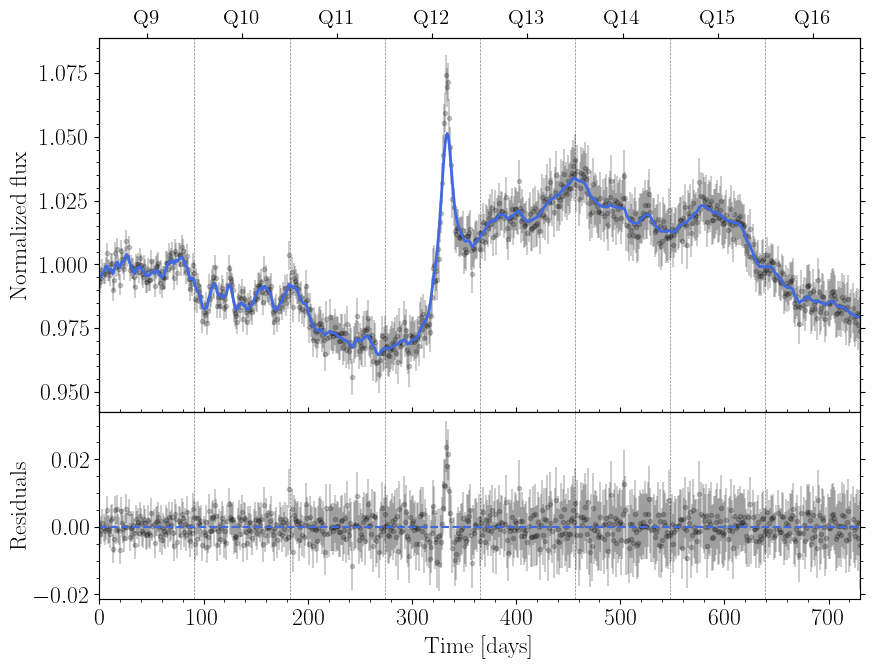

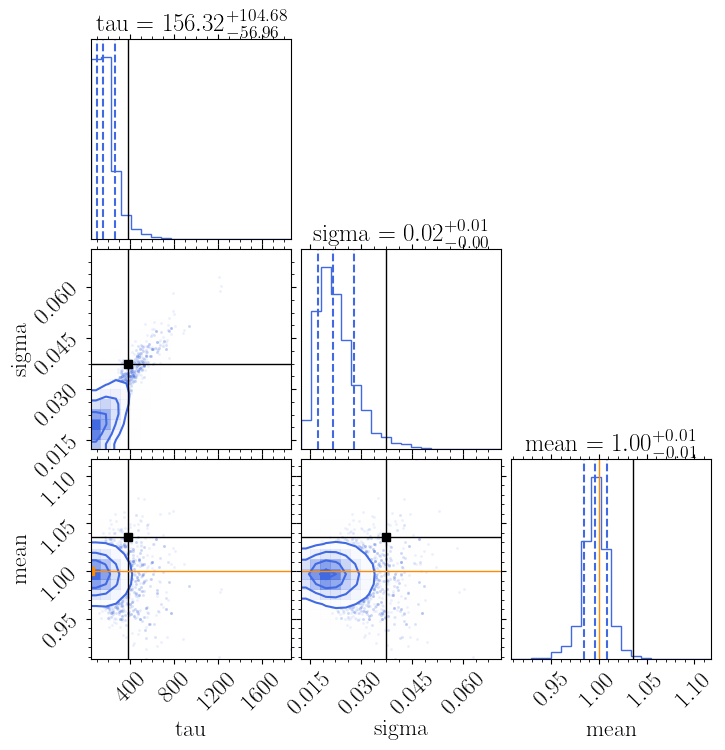

In [20]:
# Show results
dm = bs.model_lightcurve_drw(time, result)
fig, ax = pt.plot_result(df, dm, Q0=Q0)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [21]:
# Print percentiles for latex
ut.get_percentiles(result, latex=True);

tau : pmx { 156.31545 }{ -56.96247 }{ 104.68330 }
sigma : pmx { 0.02179 }{ -0.00426 }{ 0.00626 }
mean : pmx { 0.99632 }{ -0.01230 }{ 0.01163 }


---
### 1.2. Model DM
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 59522050
samples: 74148
phantom samples: 0
likelihood evals / sample: 802.7
phantom fraction (%): 0.0%
--------
logZ=2518.07 +- 0.15
max(logL)=2553.69
H=-31.62
ESS=5026
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.53 +- 0.22 | 0.26 / 0.51 / 0.86 | 0.39 | 0.39
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 0.8808 +- 0.009 | 0.8694 / 0.8807 / 0.8925 | 0.8794 | 0.8794
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: 1.71 +- 0.39 | 1.17 / 1.8 / 2.14 | 1.86 | 1.86
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.424 +- 0.016 | 0.404 / 0.424 / 0.444 | 0.42 | 0.42
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 81.44 +- 0.83 | 80.34 / 81.52 / 82.46 | 81.54 | 81.54
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM1: 6.6 +- 1.0 | 5.4 / 6.4 / 7.8 | 5.1 | 5.1
--------
logM2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM2: 6.9 +- 1.0 | 5.3 / 7.5 / 7.9 | 7.7 | 7.7
--------
t0: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
t0: 1.47 +- 0.8 | 0.89 / 0.9 / 2.59 | 0.89 | 0.89
--------
w: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
w: 178.0 +- 89.0 | 77.0 / 257.0 / 260.0 | 259.0 | 259.0
--------
CPU times: user 6h 56min 54s, sys: 3min 39s, total: 7h 34s
Wall time: 1h 6min 55s

```

In [11]:
filename = rdir / 'spikey_plato_jaxns_2yr24h_DM.npy'

In [12]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors_DM, 
#     build_mean=bs.smbhb_mean_builder,
#     build_kernel=None, 
#     ofile=filename
# )

In [13]:
result = ut.load_result(filename)

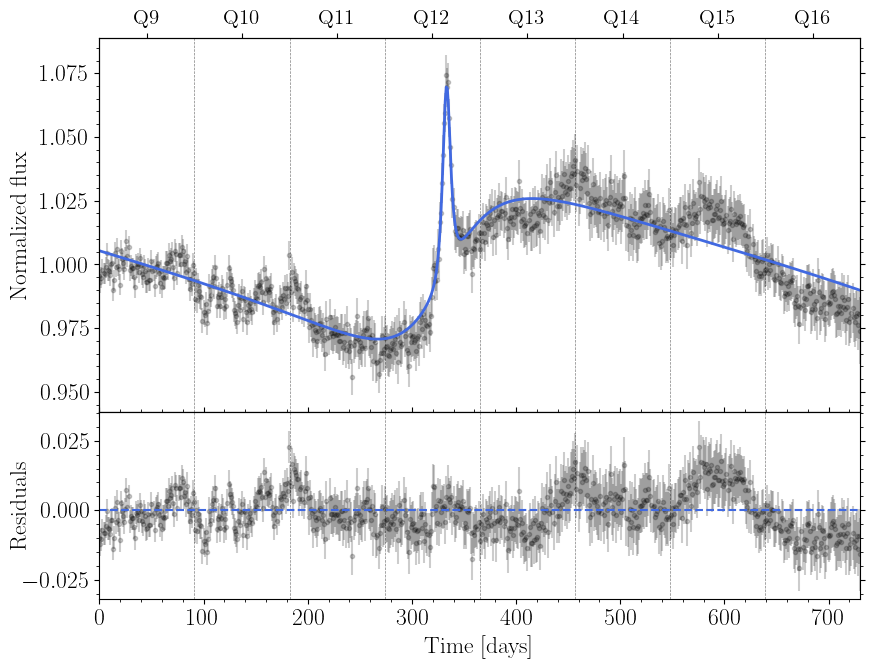

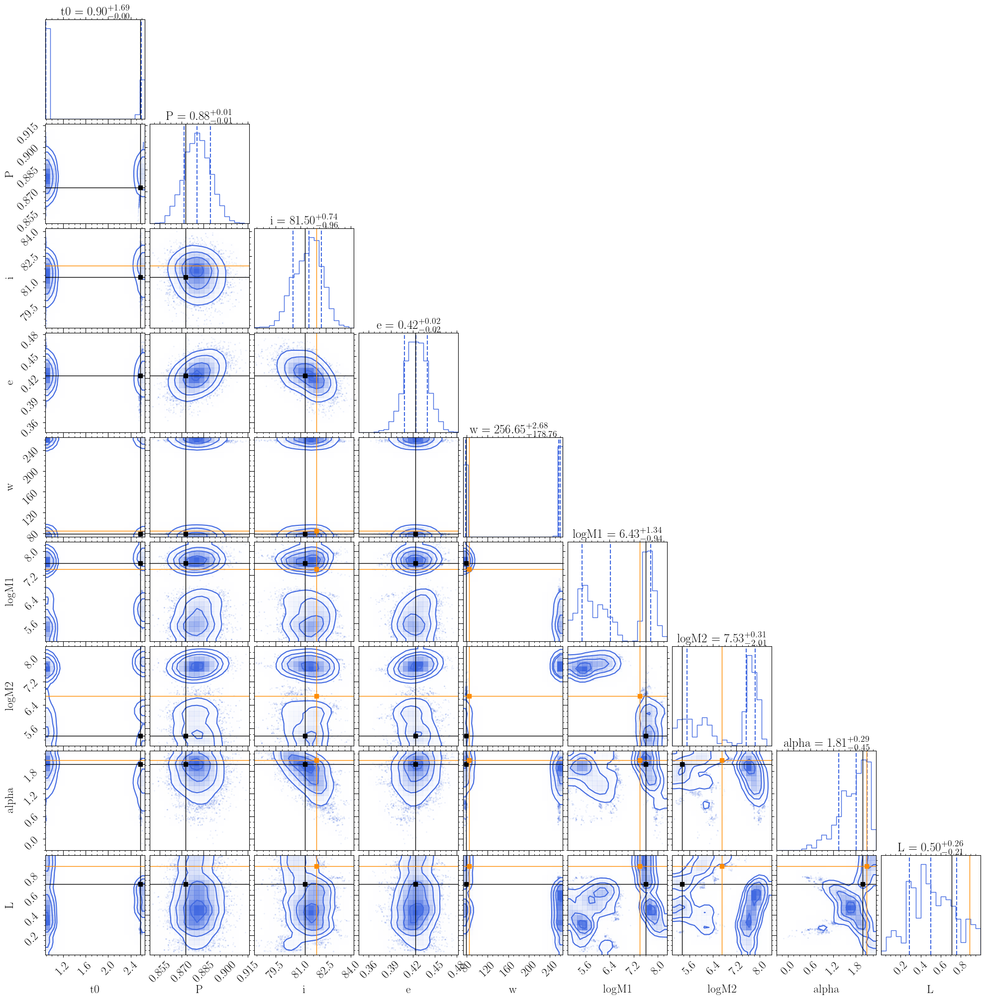

In [14]:
# Show results
dm = smbhb.model_lightcurve(time, result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, Q0=Q0)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

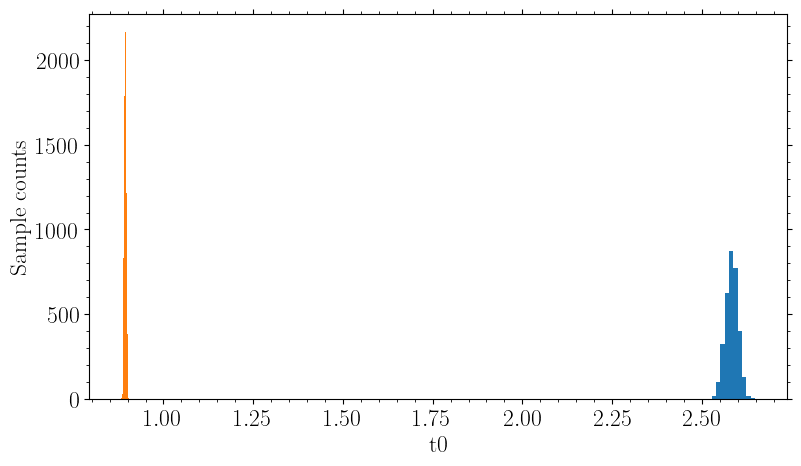

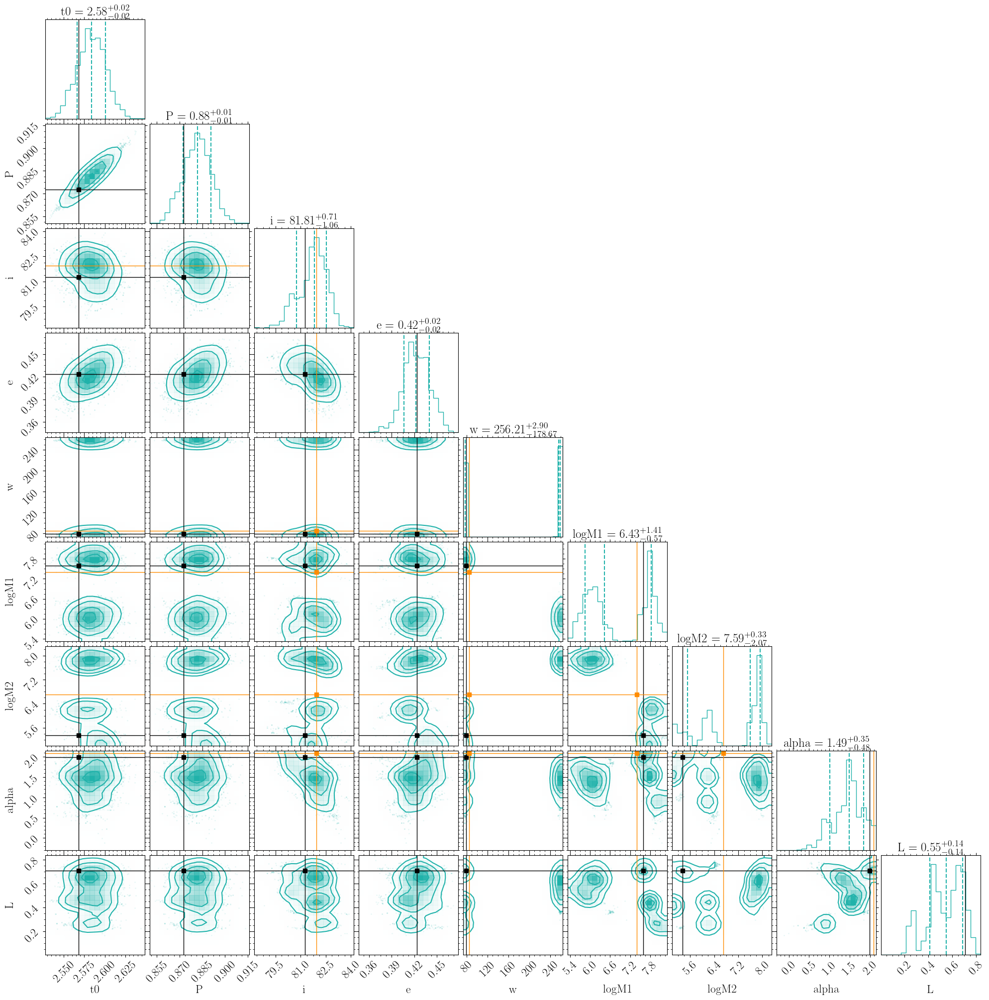

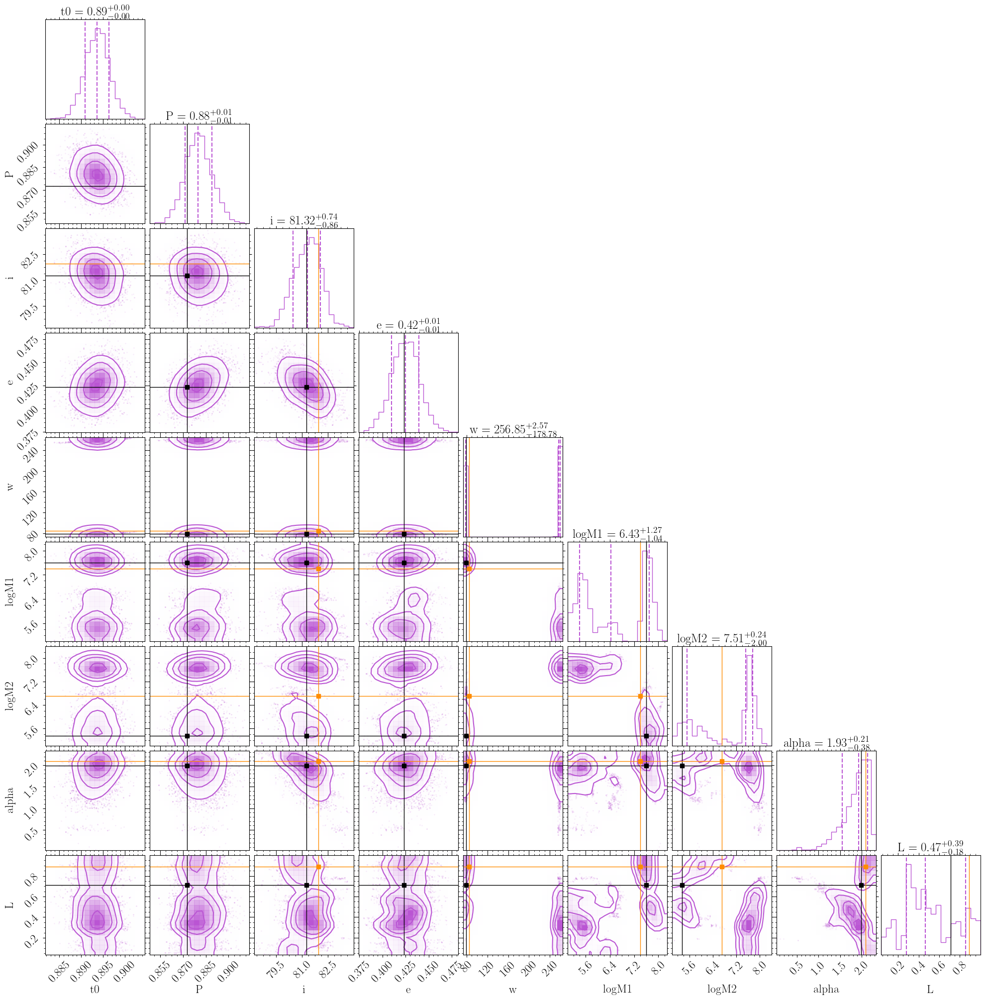

In [15]:
# Resolve bimodality in t0
clusters_t = bs.get_posterior_clusters(df, result, param_cluster='t0', n_components=2)
result_t0 = clusters_t[0]
result_t1 = clusters_t[1]
fig = pt.plot_corner(result_t0, best_params='mle', true_params=True, color=c0);
fig = pt.plot_corner(result_t1, best_params='mle', true_params=True, color=c1);

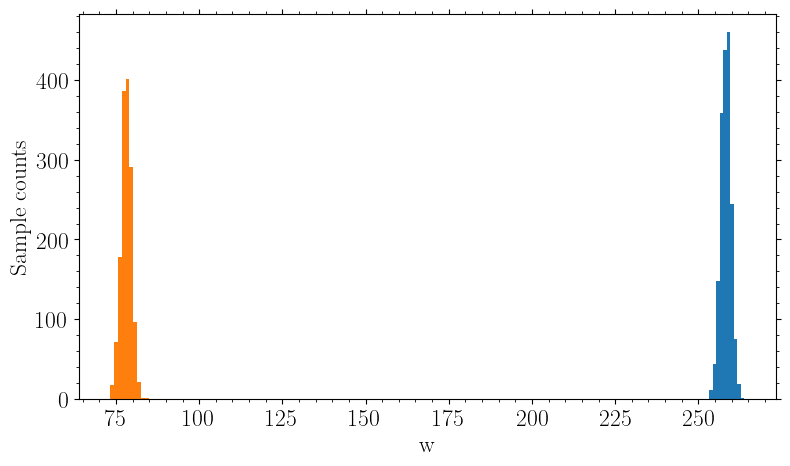

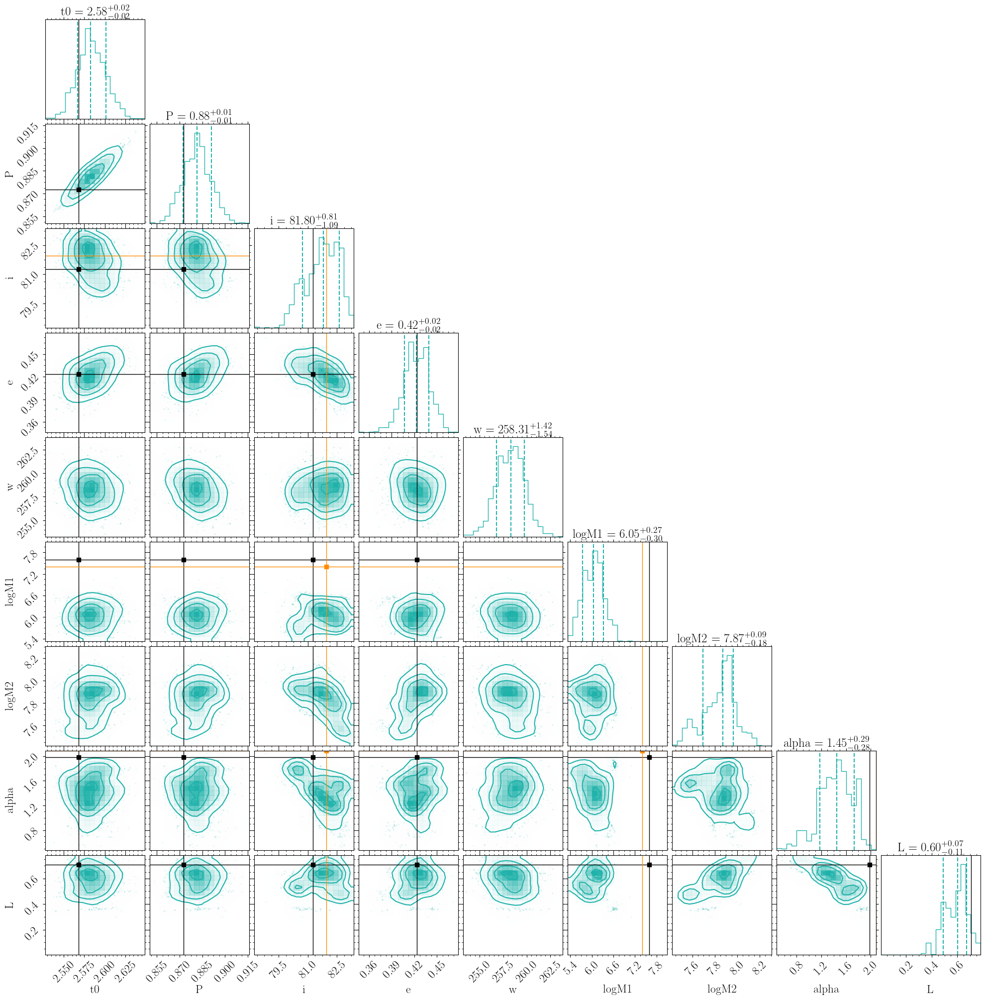

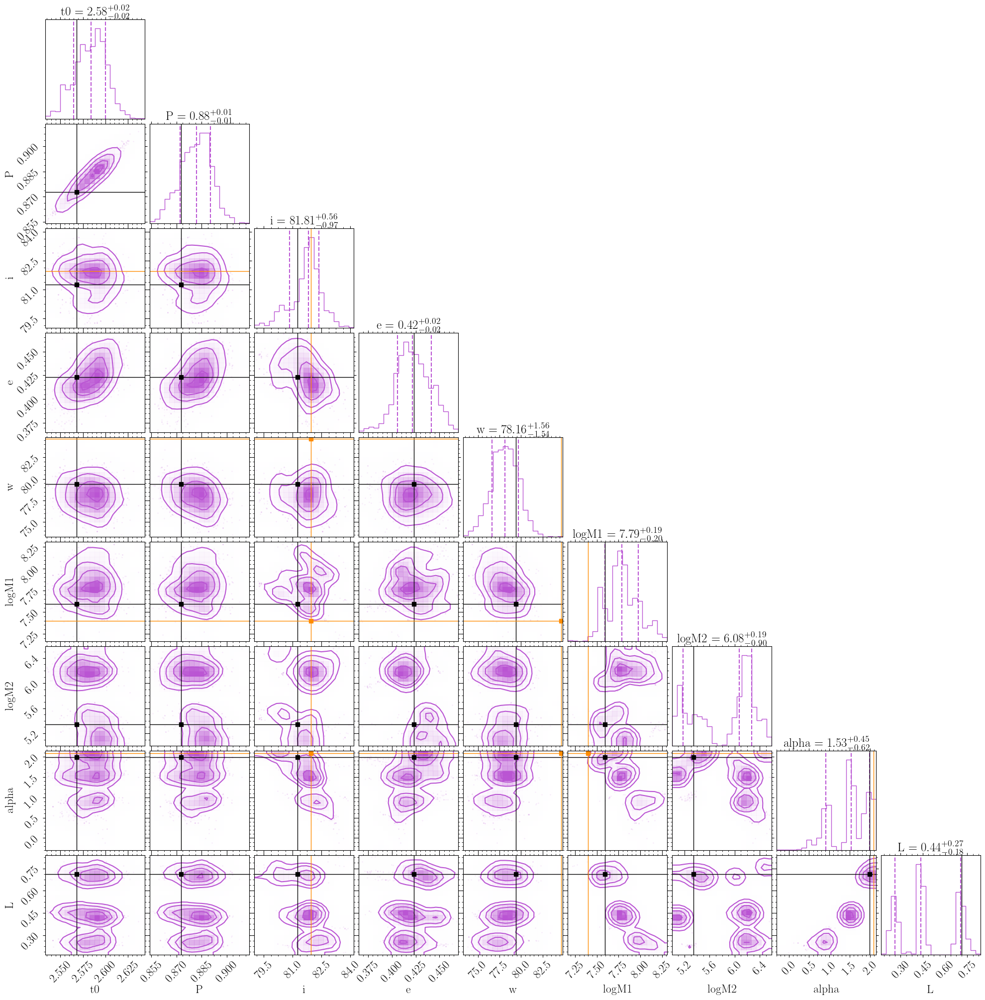

In [16]:
# Resolve bimodality in w
clusters_w = bs.get_posterior_clusters(df, result_t0, param_cluster='w', n_components=2)
result_w0 = clusters_w[0]
result_w1 = clusters_w[1]
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0);
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1);

In [17]:
# Print percentiles for latex
ut.get_percentiles(result_w0, latex=True);

t0 : pmx { 2.58280 }{ -0.01609 }{ 0.01852 }
P : pmx { 0.88166 }{ -0.00918 }{ 0.00933 }
i : pmx { 81.80456 }{ -1.08611 }{ 0.80658 }
e : pmx { 0.42281 }{ -0.01616 }{ 0.01612 }
w : pmx { 258.31047 }{ -1.53537 }{ 1.41728 }
logM1 : pmx { 6.04622 }{ -0.30218 }{ 0.27022 }
logM2 : pmx { 7.87115 }{ -0.17775 }{ 0.09255 }
alpha : pmx { 1.44746 }{ -0.27513 }{ 0.28522 }
L : pmx { 0.60376 }{ -0.11270 }{ 0.06763 }


---
### 1.3. Model QDM
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 64941562
samples: 70140
phantom samples: 0
likelihood evals / sample: 925.9
phantom fraction (%): 0.0%
--------
logZ=2698.64 +- 0.13
max(logL)=2730.5
H=-22.66
ESS=6665
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.4 +- 0.19 | 0.14 / 0.4 / 0.61 | 0.39 | 0.39
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 1.33 +- 0.99 | 0.72 / 0.92 / 3.06 | 0.76 | 0.76
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: 1.49 +- 0.86 | 0.26 / 1.69 / 2.31 | 0.63 | 0.63
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.52 +- 0.14 | 0.39 / 0.48 / 0.75 | 0.33 | 0.33
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 79.9 +- 3.1 | 76.1 / 80.2 / 83.3 | 81.5 | 81.5
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM1: 7.1 +- 1.1 | 5.5 / 7.2 / 8.3 | 7.7 | 7.7
--------
logM2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM2: 7.66 +- 0.86 | 6.1 / 7.88 / 8.39 | 7.81 | 7.81
--------
sigma: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
sigma: 0.0126 +- 0.0048 | 0.0082 / 0.0106 / 0.0201 | 0.0082 | 0.0082
--------
t0: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
t0: 0.94 +- 0.31 | 0.85 / 0.89 / 0.93 | 0.91 | 0.91
--------
tau: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
tau: 250.0 +- 200.0 | 100.0 / 160.0 / 540.0 | 140.0 | 140.0
--------
w: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
w: 218.0 +- 78.0 | 68.0 / 251.0 / 277.0 | 266.0 | 266.0
--------
CPU times: user 12h 40min 43s, sys: 48min 18s, total: 13h 29min 2s
Wall time: 4h 11min 56s

```

In [29]:
filename = rdir / 'spikey_plato_jaxns_2yr24h_QDM.npy'

In [18]:
# %%time 
# result = bs.run_jaxns(
#     df, params, priors_QDM, 
#     build_mean=bs.smbhb_mean_builder, 
#     build_kernel=bs.drw_kernel, 
#     ofile=filename
# )

In [31]:
result = ut.load_result(filename)

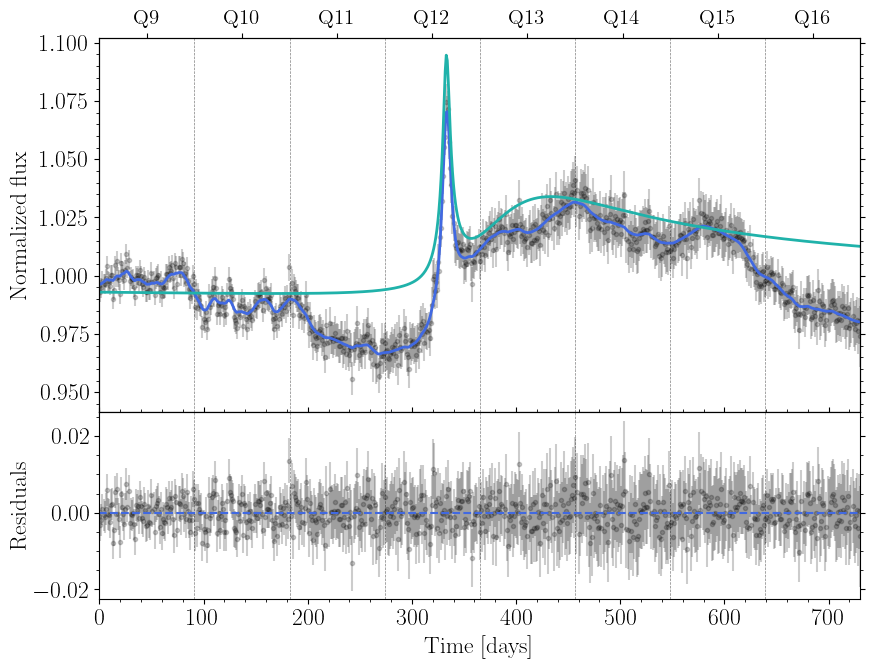

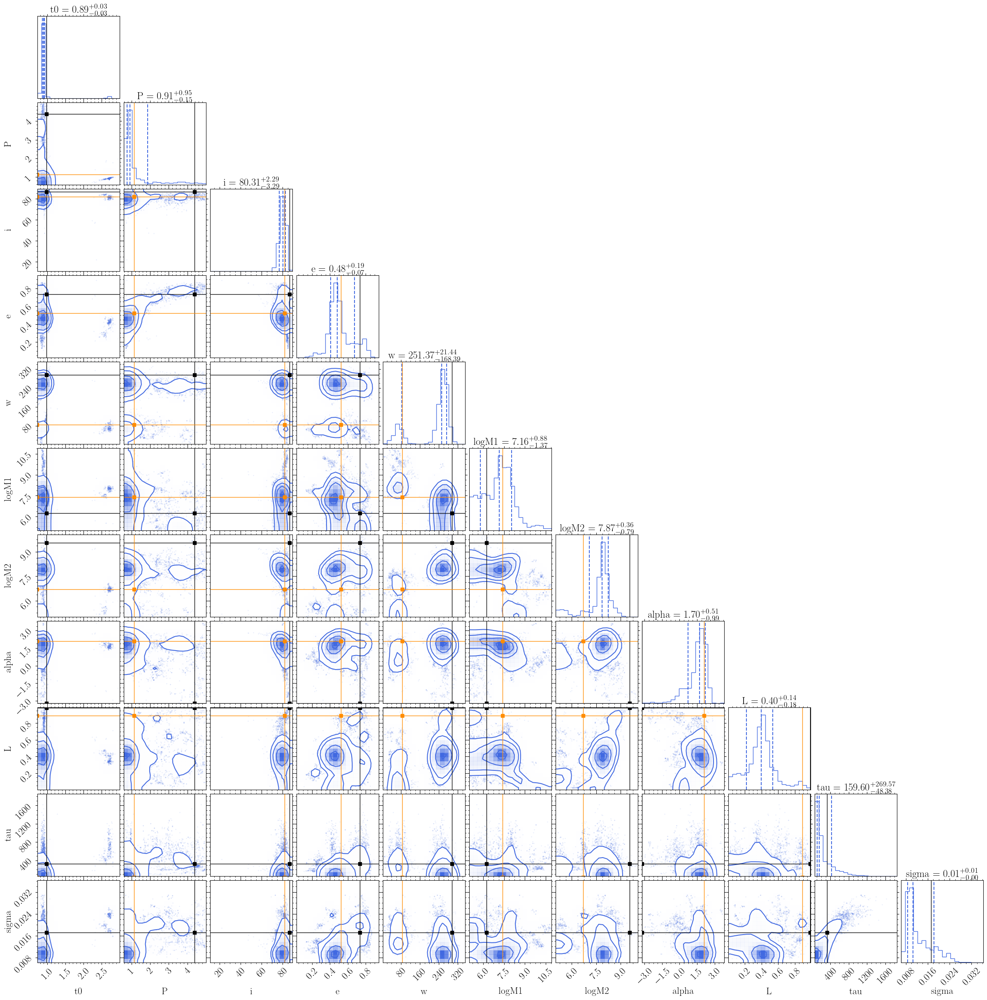

In [32]:
# Show results of QDM and DM model
dm_QDM = bs.model_lightcurve_drw(time, result)
dm_DM = smbhb.model_lightcurve(time, result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm_QDM, Q0=Q0)
ax[0].plot(dm_DM.time, dm_DM.flux, c=c0, lw=2)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

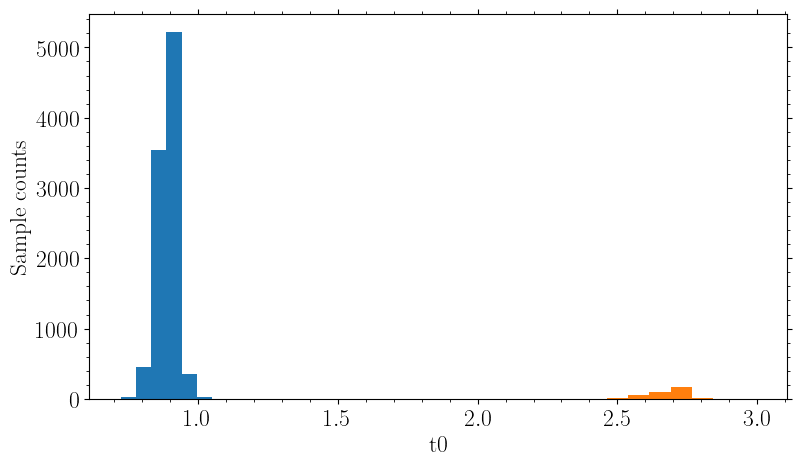

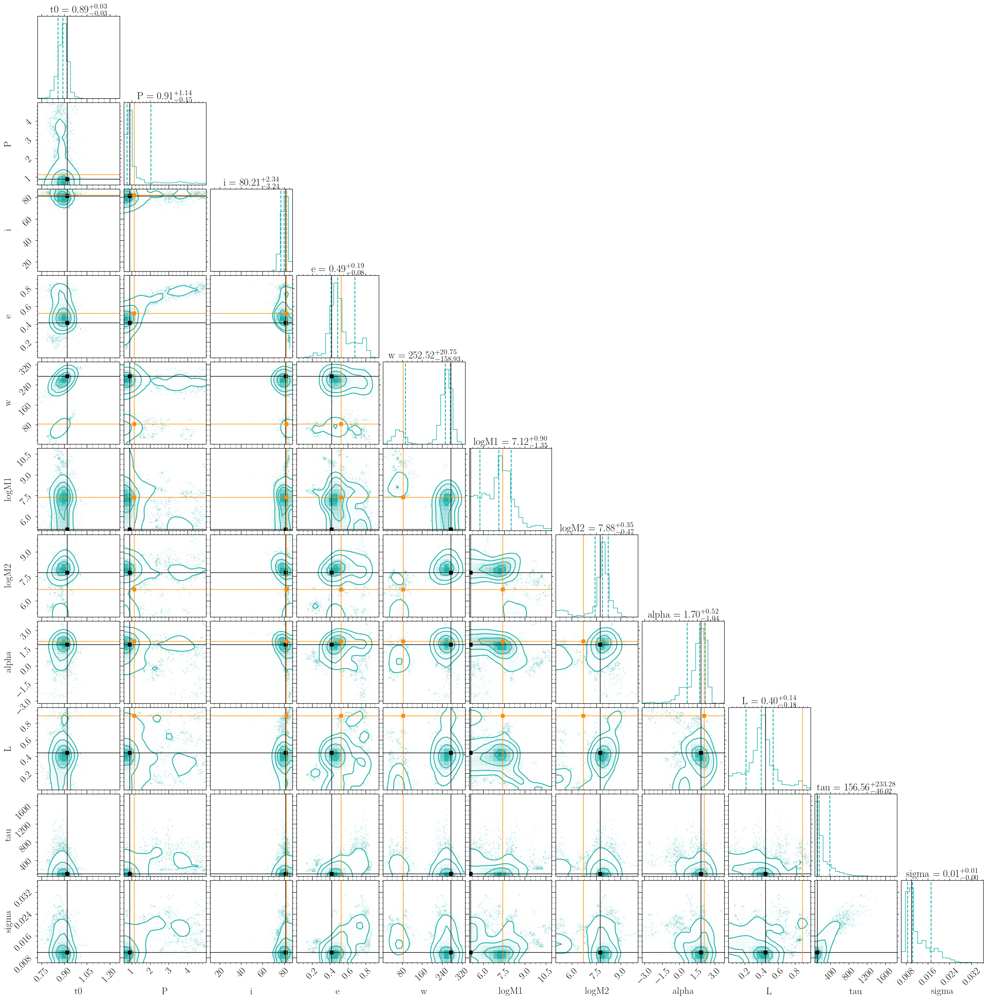

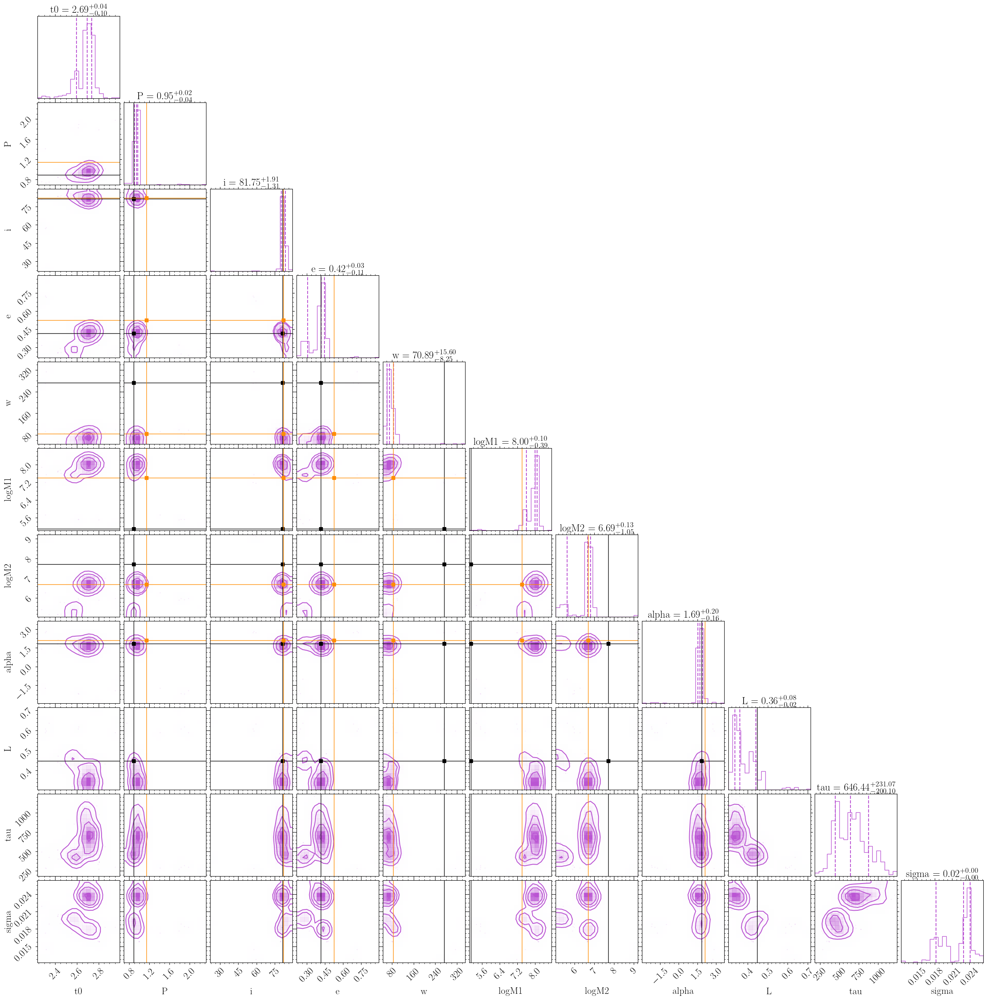

In [37]:
# Resolve bimodality in t0
clusters_t = bs.get_posterior_clusters(df, result, param_cluster='t0', n_components=2)
result_t0 = clusters_t[0]
result_t1 = clusters_t[1]
fig = pt.plot_corner(result_t0, best_params='mle', true_params=True, color=c0);
fig = pt.plot_corner(result_t1, best_params='mle', true_params=True, color=c1);

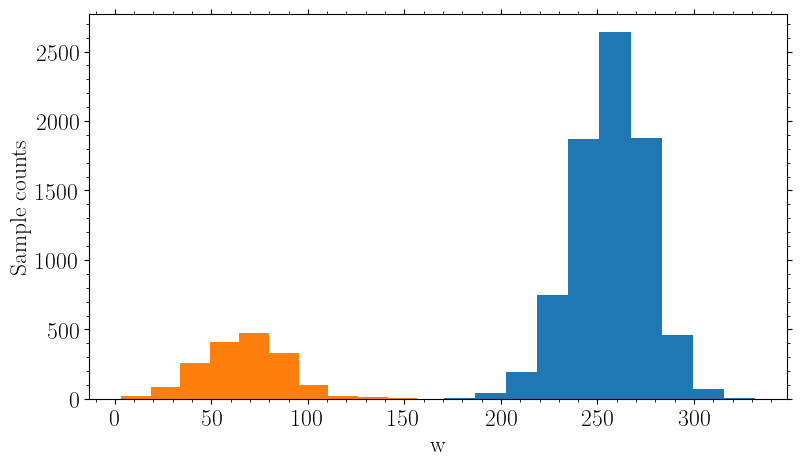

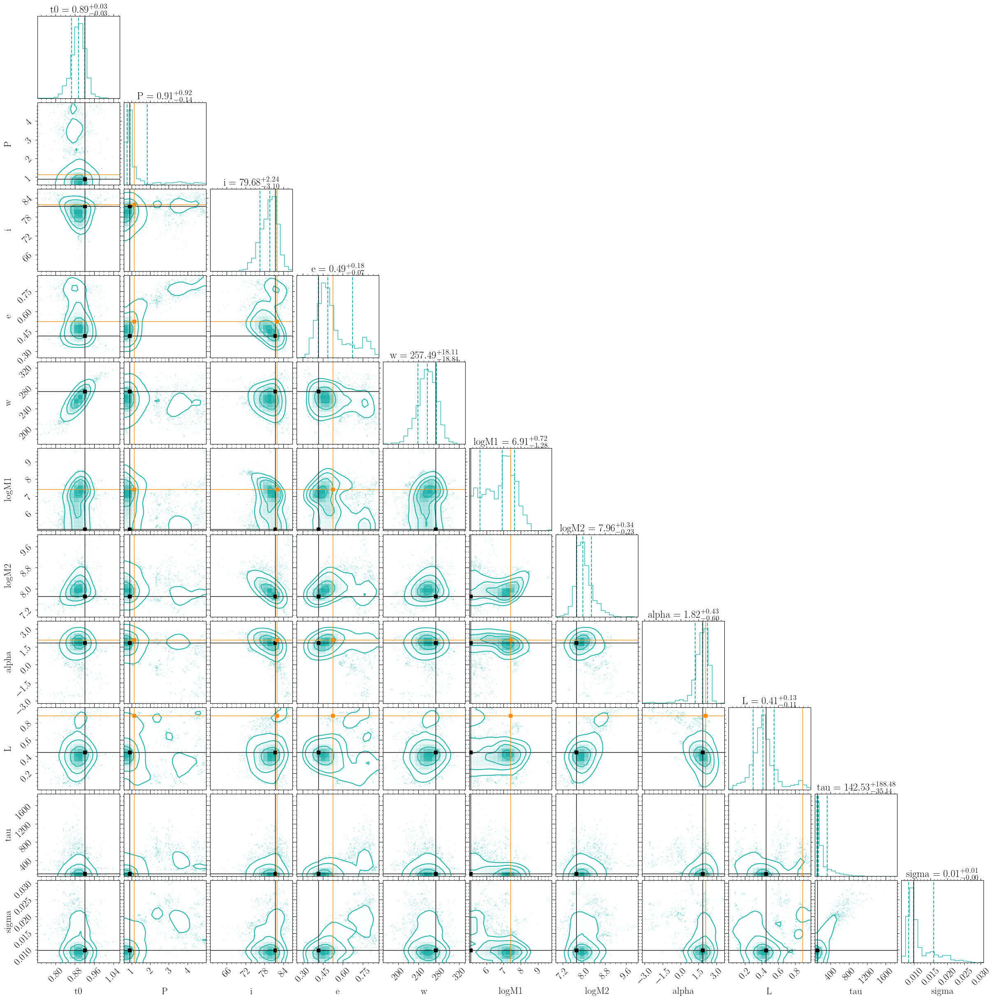

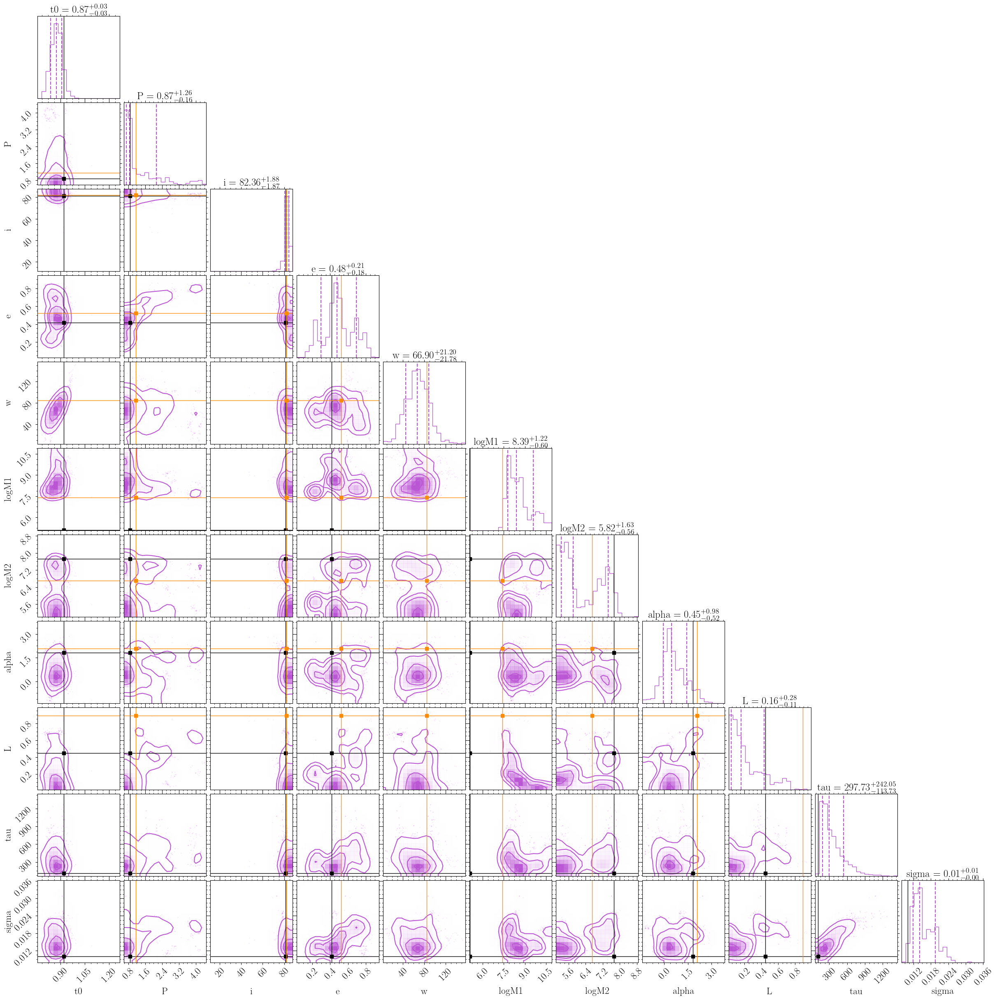

In [38]:
# Resolve bimodality in w
clusters_w = bs.get_posterior_clusters(df, result_t0, param_cluster='w', n_components=2)
result_w0 = clusters_w[0]
result_w1 = clusters_w[1]
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0);
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1);

In [40]:
# Print percentiles for latex
ut.get_percentiles(result_w0, latex=True);

t0 : pmx { 0.89468 }{ -0.02951 }{ 0.02599 }
P : pmx { 0.90947 }{ -0.14117 }{ 0.92380 }
i : pmx { 79.68317 }{ -3.10079 }{ 2.23728 }
e : pmx { 0.48818 }{ -0.07130 }{ 0.18412 }
w : pmx { 257.48506 }{ -18.83587 }{ 18.11140 }
logM1 : pmx { 6.91237 }{ -1.28425 }{ 0.72327 }
logM2 : pmx { 7.95665 }{ -0.22970 }{ 0.33511 }
alpha : pmx { 1.82496 }{ -0.59951 }{ 0.43195 }
L : pmx { 0.41436 }{ -0.11470 }{ 0.13477 }
tau : pmx { 142.53007 }{ -35.13702 }{ 188.47996 }
sigma : pmx { 0.00987 }{ -0.00146 }{ 0.00612 }


---
## 2. *Plato* 4-yr light curve
---